In [1]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


In [4]:
%pip install xgboost



   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 2.1/69.5 MB 11.8 MB/s eta 0:00:06
   -- ------------------------------------- 4.5/69.5 MB 11.7 MB/s eta 0:00:06
   --- ------------------------------------ 6.8/69.5 MB 11.7 MB/s eta 0:00:06
   ----- ---------------------------------- 9.2/69.5 MB 11.7 MB/s eta 0:00:06
   ------ --------------------------------- 11.8/69.5 MB 11.7 MB/s eta 0:00:05
   -------- ------------------------------- 14.2/69.5 MB 11.7 MB/s eta 0:00:05
   --------- ------------------------------ 16.5/69.5 MB 11.7 MB/s eta 0:00:05
   ---------- ----------------------------- 18.9/69.5 MB 11.7 MB/s eta 0:00:05
   ------------ --------------------------- 21.2/69.5 MB 11.7 MB/s eta 0:00:05
   ------------- -------------------------- 23.6/69.5 MB 11.7 MB/s eta 0:00:04
   -------------- ------------------------- 26.0/69.5 MB 11.7 MB/s eta 0:00:04
   ---------------- ----------------------- 28.3/69.5 MB 11.7 MB/

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import seaborn as sns
sns.set()

In [6]:
##load dataset
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
print(df.columns.to_list())


['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [8]:
print(df.shape)


(255347, 18)


In [9]:
df.drop("LoanID",axis=1,inplace=True)


In [10]:
binary_col = ["HasMortgage","HasDependents","HasCoSigner"]
for col in binary_col:
    df[col] = df[col].map({"yes":1,"no":0})
    

In [11]:
categorical_cols = ["Education","EmploymentType","MaritalStatus","LoanPurpose"]
for col in categorical_cols:
    df[col] = df[col].astype("category").cat.codes
df.head()


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,NaN,NaN,4,NaN,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,NaN,NaN,4,NaN,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,NaN,NaN,0,NaN,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,NaN,NaN,1,NaN,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,NaN,NaN,0,NaN,0


In [12]:
x = df.drop("Default",axis=1)
y = df["Default"]

In [13]:
##training data 75% testing 25%
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)


In [14]:
###using random forest model
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)

print("accuracy",accuracy_score(y_test,rf_pred))
print("classification report",classification_report(y_test,rf_pred))

      

accuracy 0.88544261165155
classification report               precision    recall  f1-score   support

           0       0.89      1.00      0.94     56410
           1       0.61      0.04      0.08      7427

    accuracy                           0.89     63837
   macro avg       0.75      0.52      0.51     63837
weighted avg       0.86      0.89      0.84     63837



In [18]:
##xgboost
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=(0.05),
    max_depth=4,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(x_train,y_train)
xgb_pred = xgb.predict(x_test)

print("accuracy:-",accuracy_score(y_test,xgb_pred))
print("classification report:-",classification_report(y_test,xgb_pred))

accuracy:- 0.8865861490984852
classification report:-               precision    recall  f1-score   support

           0       0.89      0.99      0.94     56410
           1       0.62      0.07      0.12      7427

    accuracy                           0.89     63837
   macro avg       0.75      0.53      0.53     63837
weighted avg       0.86      0.89      0.84     63837



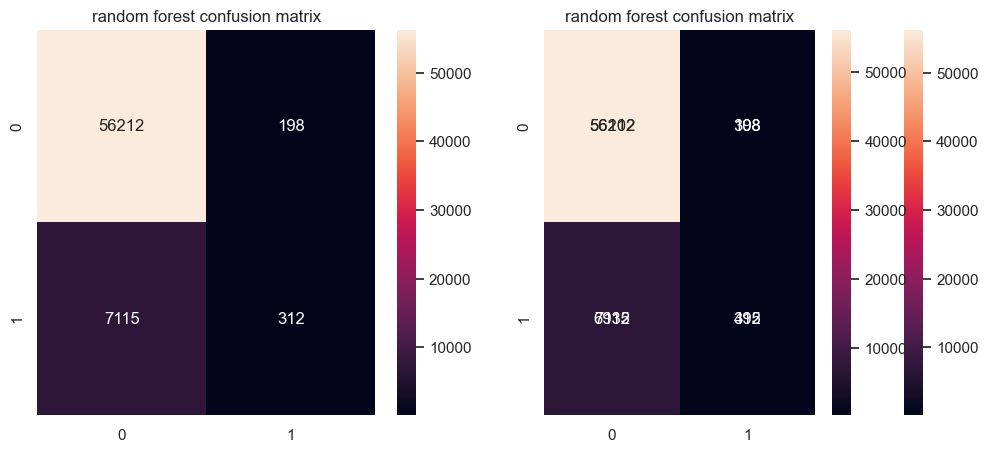

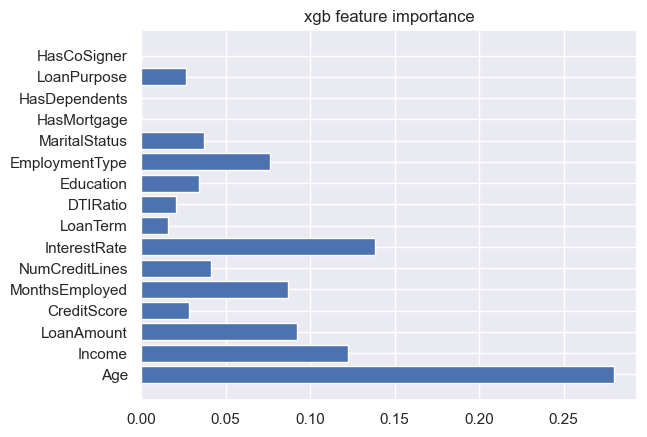

In [20]:
##confusion matrices##
fig , ax = plt.subplots(1,2,figsize=(12,5))
sns.heatmap(confusion_matrix(y_test,rf_pred),annot=True,fmt="d",ax=ax[0])

sns.heatmap(confusion_matrix(y_test,rf_pred),annot=True,fmt="d",ax=ax[1])
ax[0].set_title("random forest confusion matrix")

sns.heatmap(confusion_matrix(y_test,xgb_pred),annot=True,fmt="d",ax=ax[1])
ax[1].set_title("random forest confusion matrix")

plt.show()

importance = xgb.feature_importances_
plt.barh(x.columns,importance)
plt.title("xgb feature importance")
plt.show()
